In [30]:
# Import Libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

import lasio

In [31]:
# Input and output paths
ROOT = Path().resolve().parent
RAW  = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

In [32]:
# Check the wells and logs available in the LAS files
well_names = ["BLT-01", "JUT-01", "EVD-01", "PKP-01"]

for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df()
    df_las.index.name = "MD"    # the index is the depth column
    df_las = df_las.reset_index()

    # Replace null values (-999.25) with NaN
    df_las = df_las.replace(-999.25, float("nan"))
    df_las.to_csv(PROCESSED / f"{well}log.csv", index=False)

    print(f"\nWell Name: {well}")
    print("LAS DataFrame shape:", df_las.shape)
    print("Columns:", list(df_las.columns))
    df_las.head(8)


Well Name: BLT-01
LAS DataFrame shape: (27875, 20)
Columns: ['MD', 'BITSIZE', 'CALI', 'CASING_FLAG-(S)GR_NPHI_DTC', 'DRHO', 'DTC', 'DTS', 'DTST', 'GR', 'GRKT', 'GRTO', 'NPHI', 'PE', 'POTA', 'RD', 'RHOB', 'RM', 'RS', 'THOR', 'URAN']

Well Name: JUT-01
LAS DataFrame shape: (22427, 5)
Columns: ['MD', 'DEPT:2', 'GR', 'DT', 'RHOB']

Well Name: EVD-01
LAS DataFrame shape: (21569, 5)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO']

Well Name: PKP-01
LAS DataFrame shape: (27508, 6)
Columns: ['MD', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


In [33]:
# Load raw target lithologies data
raw_data = pd.read_csv(RAW / "target_lithologies.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                3455 non-null   str    
 1   easting                3455 non-null   float64
 2   northing               3455 non-null   float64
 3   depth_tvd_m            0 non-null      float64
 4   porosity_pct           2419 non-null   float64
 5   gamma_ray_api          3455 non-null   float64
 6   bulk_density_gcc       3199 non-null   float64
 7   formation_top_tvd      3455 non-null   float64
 8   formation_base_tvd     3455 non-null   float64
 9   formation_thickness_m  3455 non-null   float64
 10  distance_to_usp_km     3455 non-null   float64
 11  flag                   3455 non-null   str    
 12  flag_reason            3455 non-null   str    
dtypes: float64(10), str(3)
memory usage: 351.0 KB


## Checking 'well_id'

In [34]:
df = raw_data.copy() 
df['well_id'].value_counts()

well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64

## Checking empty rows

In [35]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


Missing depth_tvd_m counts per well:
well_id
BLT-01    1689
EVD-01     780
JUT-01     256
PKP-01     730
dtype: int64

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    256
dtype: int64

Missing bulk_density_gcc counts per well:
well_id
JUT-01    256
dtype: int64


### Filling in 'depth_tvd_m'

In [36]:
def fill_depth(well_id, las_file, sheet_name, top_depth, bottom_depth, md_col, gr_col):
    # Well path data
    wellpath = pd.read_excel(RAW / 'Well Path Data.xlsx', sheet_name=sheet_name)
    wellpath_df = wellpath[['Depth (m)', 'TVD (m)']]

    # Source data from LAS file
    las = pd.read_csv(PROCESSED /las_file)

    # Subset formation interval
    subset = las[(las[md_col] >= top_depth) & (las[md_col] <= bottom_depth)]
    subset = subset[[md_col, gr_col]]

    # Interpolate TVD
    subset['depth_tvd_m'] = np.interp(subset[md_col], wellpath_df['Depth (m)'], wellpath_df['TVD (m)'])

    # Merge with target lithologies
    target_subset = df[df['well_id'] == well_id]
    df.loc[target_subset.index, 'depth_tvd_m'] = subset['depth_tvd_m'].values[:len(target_subset)]

In [37]:
# Apply to all wells
fill_depth('BLT-01', 'BLT-01log.csv', 'BLT-01', 1924, 2052.7, 'MD', 'GR')
fill_depth('EVD-01', 'EVD-01log.csv', 'EVD-01', 1788, 1866, 'MD', 'GR')
fill_depth('JUT-01', 'JUT-01log.csv', 'JUT-01', 1659.5, 1787, 'MD', 'GR')
fill_depth('PKP-01', 'PKP-01log.csv', 'PKP-01', 2530.5, 2603.5, 'MD', 'GR')

In [38]:
well_list = df['well_id'].unique().tolist()
print(f"This  is a list of all the wells: {well_list}")
log_cols = ["porosity_pct", "gamma_ray_api", "bulk_density_gcc"]

This  is a list of all the wells: ['JUT-01', 'EVD-01', 'PKP-01', 'BLT-01']


## Classic 'Bulk Density' vs 'Porosity' Relationship

Well PKP-01 correlation coefficient: -0.472
Well BLT-01 correlation coefficient: -0.949


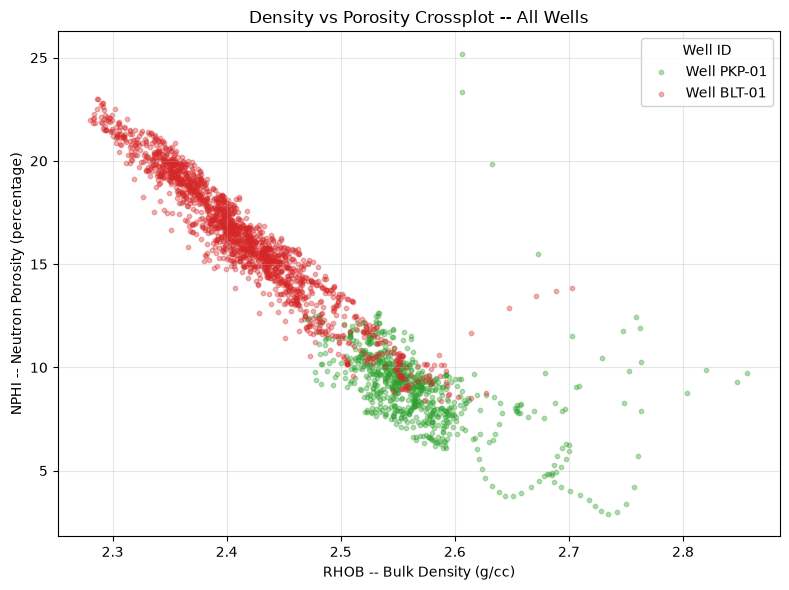

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = cm.tab10.colors

for i, well_id in enumerate(well_list):
    well_df = df[df["well_id"] == well_id]
    if well_df["bulk_density_gcc"].notna().any() and well_df["porosity_pct"].notna().any():
        ax.scatter(
            well_df["bulk_density_gcc"],
            well_df["porosity_pct"],
            alpha=0.35,
            s=10,
            color=colors[i % len(colors)],
            label=f"Well {well_id}"
        )
        corr = well_df["bulk_density_gcc"].corr(well_df["porosity_pct"])
        print(f"Well {well_id} correlation coefficient: {round(corr, 3)}")

ax.set_xlabel("RHOB -- Bulk Density (g/cc)")
ax.set_ylabel("NPHI -- Neutron Porosity (percentage)")
ax.set_title("Density vs Porosity Crossplot -- All Wells")
ax.grid(True, alpha=0.3)
ax.legend(title="Well ID", loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

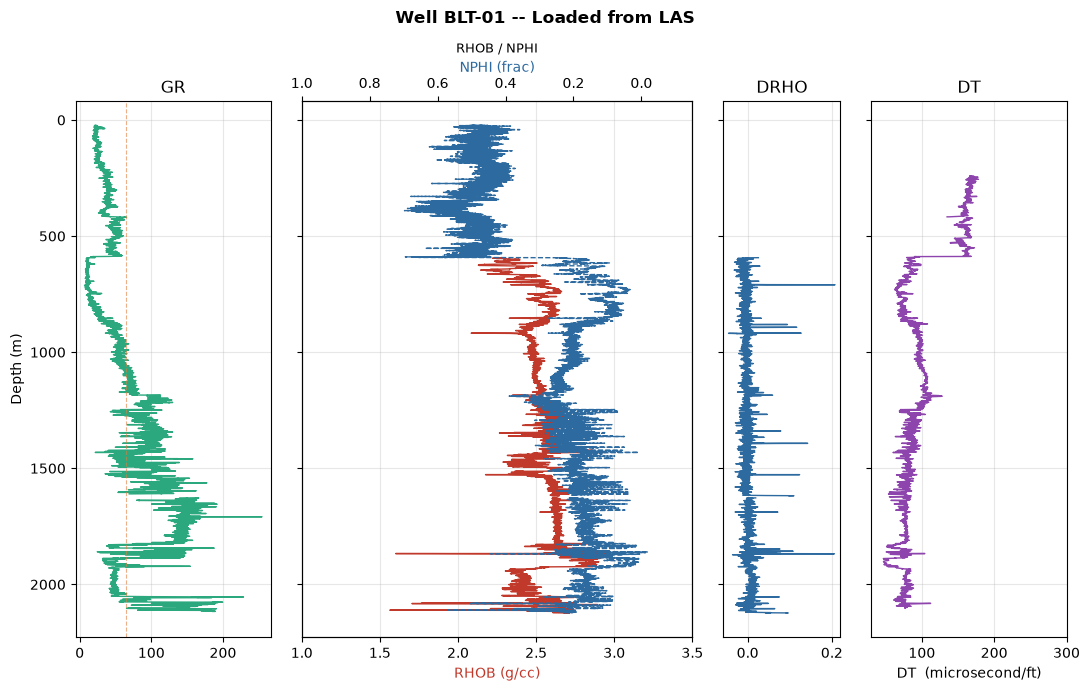

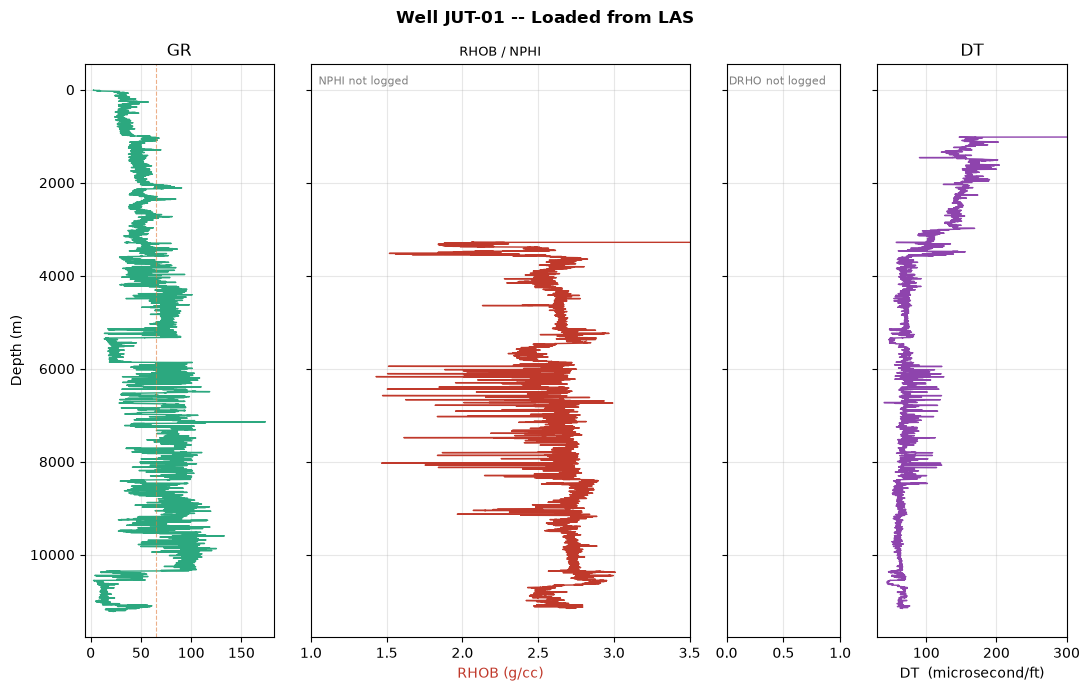

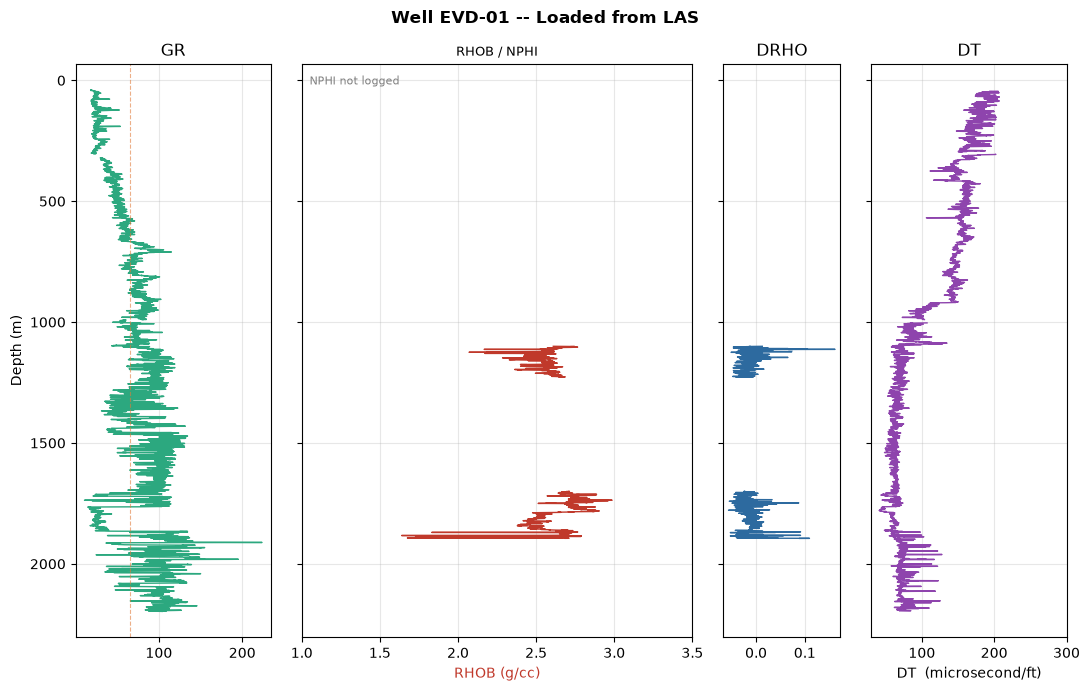

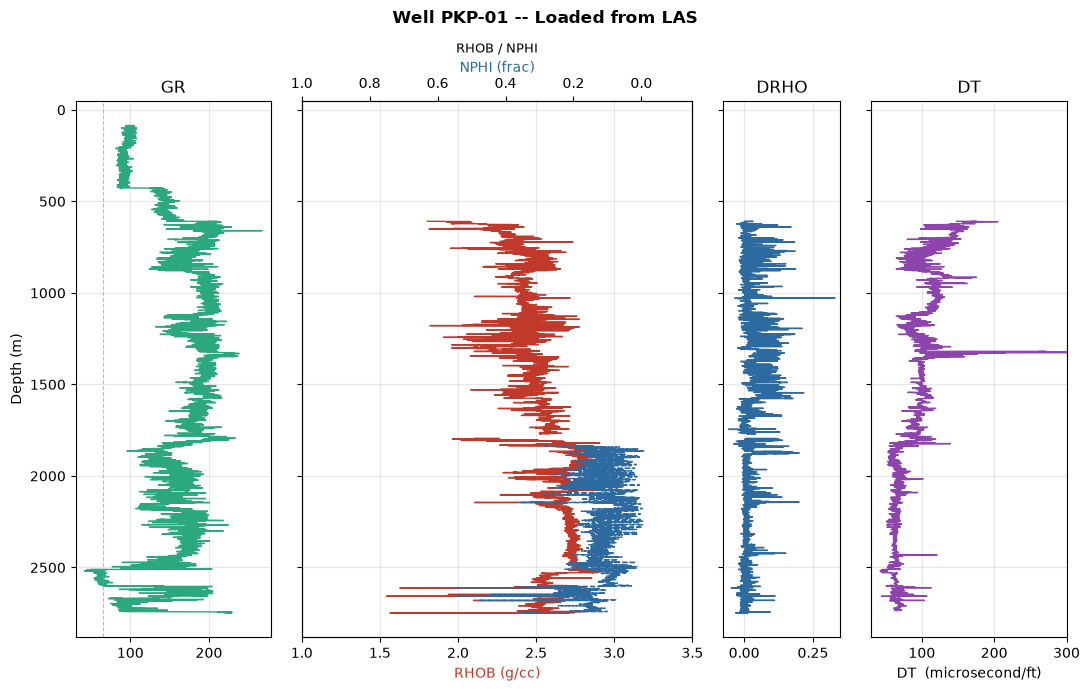

In [40]:
well_figures = {}

# GR, RHOB, NPHI, DRHO, DT/DTC logs plotted
for well in well_names:
    las = lasio.read(RAW / f"{well}.las")
    df_las = las.df()
    df_las.index.name = "MD"
    df_las = df_las.reset_index()

    df_las_clean = df_las.sort_values("MD")

    fig, axes = plt.subplots(1, 4, figsize=(11, 7), sharey=True, gridspec_kw={"width_ratios": [1, 2, 0.6, 1]})
    fig.suptitle(f"Well {well} -- Loaded from LAS", fontsize=12, fontweight="bold")

    axes[0].plot(df_las_clean["GR"], df_las_clean["MD"], color="#2ca87f", linewidth=1)
    axes[0].axvline(65, color="#e07b39", linestyle="--", linewidth=0.8, alpha=0.6)
    axes[0].set_label("GR (API)") 
    axes[0].set_title("GR") 
    axes[0].invert_yaxis() 
    axes[0].set_ylabel("Depth (m)") 

    ax2a = axes[1]
    ax2a.plot(df_las_clean["RHOB"], df_las_clean["MD"], color="#c0392b", linewidth=1, label="RHOB")
    ax2a.set_xlabel("RHOB (g/cc)", color="#c0392b")

    if "NPHI" in df_las_clean.columns:
        ax2b = ax2a.twiny()
        ax2b.plot(df_las_clean["NPHI"], df_las_clean["MD"], color="#2d6a9f", linewidth=1, linestyle="--", label="NPHI")
        ax2b.set_xlabel("NPHI (frac)", color="#2d6a9f")
    else:
        ax2a.text(0.02, 0.98, "NPHI not logged", transform=ax2a.transAxes, va="top", fontsize=8, color="gray")
    axes[1].set_title("RHOB / NPHI", fontsize=9) 
    ax2a.set_xlim(1.0, 3.5)
    ax2b.set_xlim(1.0, -0.15)

    if "DRHO" in df_las_clean.columns:
        axes[2].plot(df_las_clean["DRHO"], df_las_clean["MD"], color="#2d6a9f", linewidth=1)
        axes[2].set_label("DRHO  (g/cc)")
        axes[2].set_title("DRHO")
    else:
        axes[2].text(0.02, 0.98, "DRHO not logged", transform=axes[2].transAxes, va="top", fontsize=8, color="gray")

    dt_col = "DT" if "DT" in df_las_clean.columns else ("DTC" if "DTC" in df_las_clean.columns else None)

    axes[3].plot(df_las_clean[dt_col], df_las_clean["MD"], color="#8e44ad", linewidth=1)
    axes[3].set_xlabel("DT  (microsecond/ft)")
    axes[3].set_title("DT")
    axes[3].set_xlim(30, 300)

    for ax in axes: 
        ax.grid(True, alpha=0.3)

    well_figures[well] = fig 
    plt.tight_layout() 
    plt.show()

### Velocity(DT Log) and Bulk Density(RHOB) Relationship

In [ ]:
from sklearn.linear_model import LinearRegression

results = []
for well in well_list:
    las = lasio.read(RAW / f"{well}.las")
    d = las.df().reset_index()
    if "RHOB" not in d.columns or not any(c in d.columns for c in ["DT", "DTC"]):
        continue
    dt_col = "DT" if "DT" in d.columns else "DTC"
    sub = d[[dt_col, "RHOB"]].dropna()
    sub = sub[sub[dt_col].between(30, 300) & sub["RHOB"].between(1.0, 3.5)]

    V = 1e6 / sub[dt_col]
    logV, logRho = np.log(V), np.log(sub["RHOB"])
    lr = LinearRegression().fit(logV.values.reshape(-1, 1), logRho)
    b, a, r2 = lr.coef_[0], np.exp(lr.intercept_), lr.score(logV.values.reshape(-1, 1), logRho)
    results.append({"well": well, "n": len(sub), "a_fit": round(a, 4), "b_fit": round(b, 4), "r2": round(r2, 3)})

fit_table = pd.DataFrame(results)
print(fit_table.to_string(index=False))
print("\nStandard Gardner: a=0.23, b=0.25")

  well     n  a_fit  b_fit    r2
JUT-01 15747 0.1509 0.2975 0.434
EVD-01  3181 0.6363 0.1454 0.135
PKP-01 20981 0.4138 0.1935 0.646
BLT-01 19696 0.5998 0.1532 0.249

Standard Gardner: a=0.23, b=0.25


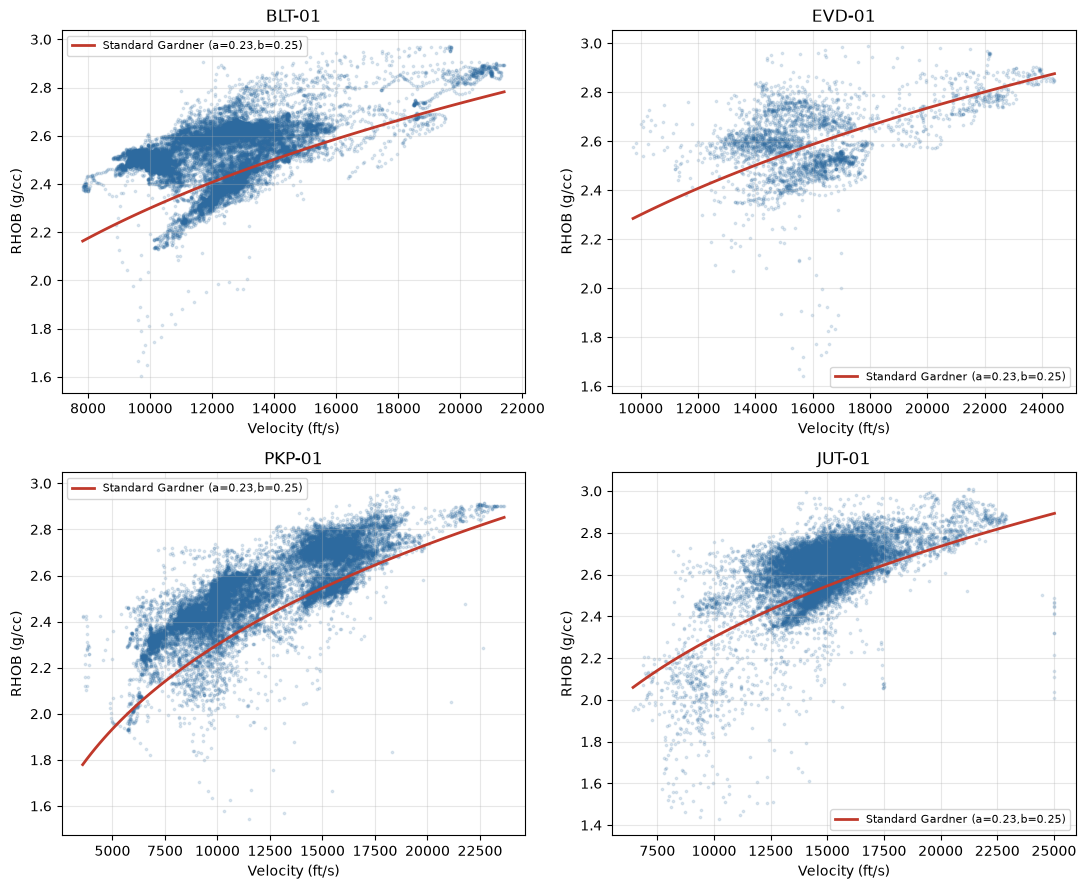

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, well in zip(axes, ["BLT-01", "EVD-01", "PKP-01", "JUT-01"]):
    las = lasio.read(RAW / f"{well}.las")
    d = las.df().reset_index()
    dt_col = "DT" if "DT" in d.columns else "DTC"
    sub = d[[dt_col, "RHOB"]].dropna()
    sub = sub[sub[dt_col].between(30, 300) & sub["RHOB"].between(1.0, 3.5)]
    V = 1e6 / sub[dt_col]

    ax.scatter(V, sub["RHOB"], s=3, alpha=0.15, color="#2d6a9f")
    V_range = np.linspace(V.min(), V.max(), 100)
    ax.plot(V_range, 0.23 * V_range**0.25, color="#c0392b", linewidth=2, label="Standard Gardner (a=0.23,b=0.25)")

    ax.set_xlabel("Velocity (ft/s)")
    ax.set_ylabel("RHOB (g/cc)")
    ax.set_title(well)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

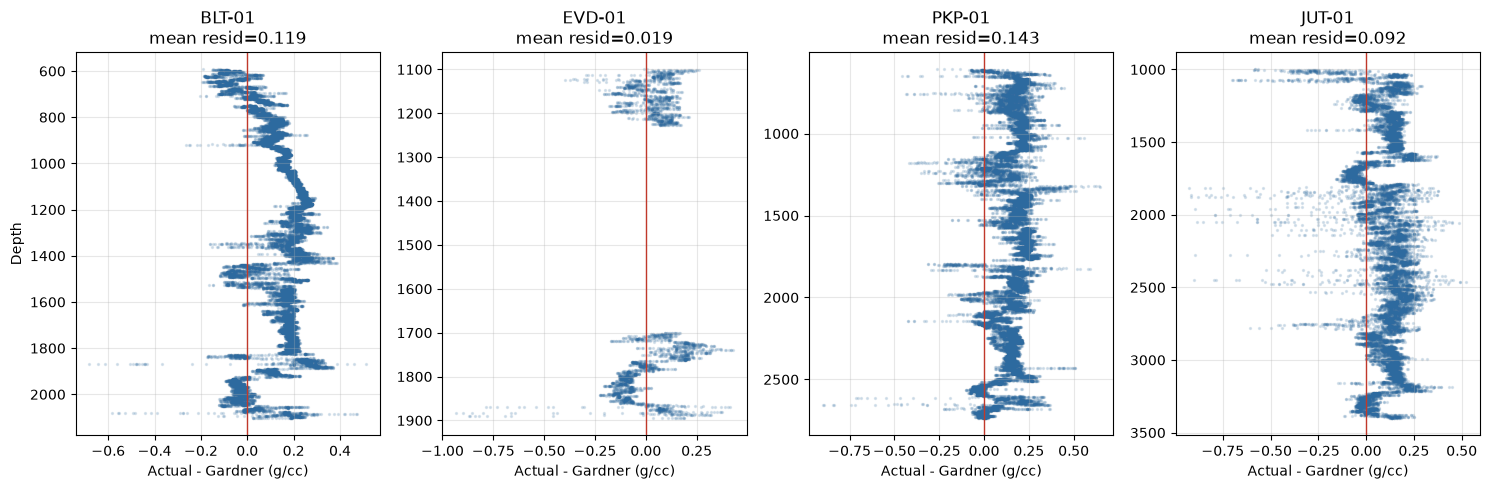

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for ax, well in zip(axes, ["BLT-01", "EVD-01", "PKP-01", "JUT-01"]):
    las = lasio.read(RAW / f"{well}.las")
    d = las.df().reset_index()
    dt_col = "DT" if "DT" in d.columns else "DTC"
    depth_col = "MD" if "MD" in d.columns else ("DEPT:2" if "DEPT:2" in d.columns else "DEPT")
    sub = d[[dt_col, "RHOB", depth_col]].dropna()
    sub = sub[sub[dt_col].between(30, 300) & sub["RHOB"].between(1.0, 3.5)]

    V = 1e6 / sub[dt_col]
    pred = 0.23 * V**0.25
    residual = sub["RHOB"] - pred

    ax.scatter(residual, sub[depth_col], s=2, alpha=0.15, color="#2d6a9f")
    ax.axvline(0, color="#c0392b", linewidth=1)
    ax.invert_yaxis()
    ax.set_title(f"{well}\nmean resid={residual.mean():.3f}")
    ax.set_xlabel("Actual - Gardner (g/cc)")
    if ax is axes[0]:
        ax.set_ylabel("Depth")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Filling in 'bulk_density_gcc'

#### Gardner's Relation

$$ \rho = 0.23 V_p^{0.25} $$

Where:
* $\rho$ = Bulk density ($\text{g/cm}^3$)
* $V_p$ = P-wave velocity ($\text{ft/s}$)

In [48]:
las_jut = lasio.read(RAW / "JUT-01.las")
d = las_jut.df().reset_index()

# Subset formation interval
subset = d[(d['DEPT:1'] >= 1659.5) & (d['DEPT:1'] <= 1787)].copy()
subset['DT'] = subset['DT'].where(subset['DT'].between(30, 300))

# Apply Gardner's Relation + Mean Residual Correction
subset['V_ft_s'] = 1e6 / subset['DT']
subset['bulk_density_gardner'] = 0.23 * subset['V_ft_s'] ** 0.25 + 0.092 

jut01_idx = df[df['well_id'] == 'JUT-01'].index
df.loc[jut01_idx, 'bulk_density_gcc'] = subset['bulk_density_gardner'].values[:len(jut01_idx)]

print(df.loc[jut01_idx, 'bulk_density_gcc'].describe())

count    256.000000
mean       2.113648
std        0.030115
min        2.025760
25%        2.099824
50%        2.120916
75%        2.135559
max        2.165208
Name: bulk_density_gcc, dtype: float64
